# RNA/ATAC integration tutorial

This tutorial demonstrates how to use Champollion on a PBMC dataset with RNA and ATAC modalities. The dataset used here is already preprocessed. For guidance on preparing a new dataset, see the Data Inputs section of the documentation.

This tutorial aims at illustrating on a concrete example the different steps of the workflow, focusing specifically on the integration of unpaired cells. For more details on interpretability of the learnt parameters, see the interpretability tutorial. Here, Champollion learns the cross-modality cost on the bridge, then uses it to integrate the unpaired cells, transfer annotations, and build joint visualizations.



In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

from champollion import Champollion
from champollion.plot import plot_ordered_transport_plan

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


## Configuration


In [3]:
DATA_PATH = Path("../semi-paired/data/pbmc_all/incomplete.h5mu")

RNA_MOD = "rna"
ATAC_MOD = "atac"
CELLTYPE_KEY = "celltype"

## Load the data

In [4]:
mdata = mu.read_h5mu(DATA_PATH)
print(mdata)
print("modalities:", list(mdata.mod.keys()))

MuData object with n_obs × n_vars = 5637 × 145834
  obs:	'celltype', 'paired_mask'
  var:	'gene_ids', 'interval', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'variability_score', 'mean', 'std'
  uns:	'dataset_name'
  2 modalities
    atac:	5637 × 130417
      obs:	'celltype', 'batch', 'n_genes'
      var:	'gene_ids', 'interval', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'variability_score', 'mean', 'std'
      uns:	'gene_activities_var_names', 'hvg', 'log1p'
      obsm:	'X_pca', 'gene_activities', 'prior_data'
      layers:	'counts', 'scaled'
    rna:	5637 × 15417
      obs:	'celltype', 'batch', 'n_genes'
      var:	'gene_ids', 'interval', 'strand', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'variability_score', 'mean', 'std'
      uns:	'hvg', 'log1p'
      obsm:	'X_pca', 'prior_data'
      layers:	'counts', 'scaled'
modalities: ['atac', 'rna']


## Prepare the tutorial inputs

For simplicity, we used a paired available Multiome dataset. Because this dataset is fully paired, every cell has both modalities. To mimic the setting Champollion is designed for, we use part of the cells as the paired bridge and treat the remaining cells as pseudo-unpaired RNA and ATAC profiles.

In a typical application, the bridge would come from a paired assay such as multiome, while the unpaired cells could come from separate scRNA-seq and scATAC-seq experiments.

The `paired_mask` column is used here only to construct a tutorial split: cells marked as paired form the bridge, and the remaining cells are copied into two modality-specific `AnnData` objects that we deliberately treat as unpaired. After this preparation step (whose details will not interest most users), we will have three objects: one bridge `MuData` object used for fitting, plus one pseudo-unpaired RNA object and one pseudo-unpaired ADT object used for transport and interpretation.

In [5]:
# Debug mode keeps the notebook executable on a cpu. Set DEBUG = False on the cluster.
DEBUG = False
DEBUG_TRAIN_CELLS = 120
DEBUG_TEST_CELLS = 180

PAIRED_MASK_KEY = "paired_mask"
paired_mask = np.asarray(mdata.obs[PAIRED_MASK_KEY].to_numpy(), dtype=bool)
celltypes = mdata.obs[CELLTYPE_KEY].astype(str).to_numpy()

def stratified_indices(mask, labels, n=None, random_state=0):
    """Return indices within mask, optionally stratified down to n cells."""
    idx = np.flatnonzero(mask)
    if n is None or n >= len(idx):
        return idx
    rng = np.random.default_rng(random_state)
    selected = []
    present_labels = [
        label for label in pd.unique(labels[idx]) if np.any(labels[idx] == label)
    ]
    per_group = max(1, int(np.ceil(n / len(present_labels))))
    for label in present_labels:
        label_idx = idx[labels[idx] == label]
        take = min(per_group, len(label_idx))
        selected.extend(rng.choice(label_idx, size=take, replace=False))
    selected = np.asarray(selected, dtype=int)
    if len(selected) > n:
        selected = rng.choice(selected, size=n, replace=False)
    return np.sort(selected)


train_idx = stratified_indices(
    paired_mask,
    labels=celltypes,
    n=DEBUG_TRAIN_CELLS if DEBUG else None,
    random_state=0,
)
test_idx = stratified_indices(
    ~paired_mask,
    labels=celltypes,
    n=DEBUG_TEST_CELLS if DEBUG else None,
    random_state=1,
)

bridge_mdata = mu.MuData(
    {
        RNA_MOD: mdata.mod[RNA_MOD][train_idx].copy(),
        ATAC_MOD: mdata.mod[ATAC_MOD][train_idx].copy(),
    }
)

adata_rna = mdata.mod[RNA_MOD][test_idx].copy()
adata_atac = mdata.mod[ATAC_MOD][test_idx].copy()

In [6]:
pd.crosstab(mdata.obs[CELLTYPE_KEY], mdata.obs[PAIRED_MASK_KEY], colnames=["paired"])

paired,False,True
celltype,,
CD56 (bright) NK cells,400,0
CD56 (dim) NK cells,452,0
classical monocytes,911,912
memory CD4 T cells,766,766
naive CD8 T cells,715,715


In [7]:
print(bridge_mdata)
print("pseudo-unpaired RNA:", adata_rna.shape)
print("pseudo-unpaired ATAC:", adata_atac.shape)

MuData object with n_obs × n_vars = 2393 × 145834
  var:	'gene_ids', 'interval', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'variability_score', 'mean', 'std'
  2 modalities
    rna:	2393 × 15417
      obs:	'celltype', 'batch', 'n_genes'
      var:	'gene_ids', 'interval', 'strand', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'variability_score', 'mean', 'std'
      uns:	'hvg', 'log1p'
      obsm:	'X_pca', 'prior_data'
      layers:	'counts', 'scaled'
    atac:	2393 × 130417
      obs:	'celltype', 'batch', 'n_genes'
      var:	'gene_ids', 'interval', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'variability_score', 'mean', 'std'
      uns:	'gene_activities_var_names', 'hvg', 'log1p'
      obsm:	'X_pca', 'gene_activities', 'prior_data'
      layers:	'counts', 'scaled'
pseudo-unpaired RNA: (3244, 15417)
pseudo-unpaired ATAC: (3244, 130417)


## Fit Champollion on the paired bridge

The representations used here are low-dimensional RNA/ATAC embeddings stored in `.obsm`; the prior representation provides a common space used to compute a prior cost, it was obtained by computing gene activities for ATAC profiles with `Signac`.

Champollion learns the sparse cross-modality matrix `A` from the bridge cells. The bridge contains matched RNA and ATAC profiles for the same cells, so it provides the supervision needed to learn how the two representation spaces should be compared.

The verbose optimization log from the server run is shortened in this rendered notebook to keep the tutorial readable.

In [8]:
model = Champollion(
    epsilon=1.0,
    gamma=0.01,
    lambda_prior=20.0,
    use_keops=False,
    device="auto",
    random_state=0,
    max_iter=3 if DEBUG else 300_000,
    learning_rate=1e-3,
    sinkhorn_tol=1e-3,
    log_every=1 if DEBUG else 40,
    verbose=True
)
model.fit(
    bridge_mdata,
    modality_1=RNA_MOD,
    modality_2=ATAC_MOD,
    x_1_rep="obsm/X_pca",
    x_2_rep="obsm/X_pca",
    y_prior_1_rep="obsm/prior_data",
    y_prior_2_rep="obsm/prior_data",
)

print("A shape:", tuple(model.A_.shape))
print("A device:", model.A_.device)
pd.DataFrame(
    {key: pd.Series(value) for key, value in model.training_history_.items()}
).tail()

  0%|          | 38/300000 [00:00<36:39, 136.35it/s] 

train_total_loss: 23.648801803588867
train_obj_loss: 23.396228790283203
train_reg_loss: 0.2525726854801178
train_trace_term: -7.785801887512207
train_err_1: 1.797552227973938
train_plan_mass: 1.0000007152557373
train_total_loss: -9.479005813598633
train_obj_loss: -9.688580513000488
train_reg_loss: 0.20957428216934204
train_trace_term: -20.96923065185547
train_err_1: 1.535330057144165
train_plan_mass: 1.0000001192092896


  0%|          | 152/300000 [00:00<16:32, 302.05it/s]

train_total_loss: -16.77338218688965
train_obj_loss: -16.960758209228516
train_reg_loss: 0.18737666308879852
train_trace_term: -21.96637725830078
train_err_1: 1.1960947513580322
train_plan_mass: 1.0000001192092896
train_total_loss: -19.098215103149414
train_obj_loss: -19.268360137939453
train_reg_loss: 0.17014560103416443
train_trace_term: -19.65060806274414
train_err_1: 0.9687426090240479
train_plan_mass: 1.0


  0%|          | 226/300000 [00:00<14:55, 334.76it/s]

...

  9%|▊         | 25868/300000 [01:16<12:24, 368.13it/s]

train_total_loss: -22.764774322509766
train_obj_loss: -22.864282608032227
train_reg_loss: 0.0995083600282669
train_trace_term: -47.513328552246094
train_err_1: 0.015511035919189453
train_plan_mass: 1.0000004768371582
train_total_loss: -22.76526641845703
train_obj_loss: -22.864784240722656
train_reg_loss: 0.09951744973659515
train_trace_term: -47.49102783203125
train_err_1: 0.0020169296767562628
train_plan_mass: 1.000000238418579


  9%|▊         | 25920/300000 [01:16<13:28, 338.88it/s]


train_total_loss: -22.765281677246094
train_obj_loss: -22.864805221557617
train_reg_loss: 0.09952424466609955
train_trace_term: -47.48903274536133
train_err_1: 0.001074271509423852
train_plan_mass: 1.0000003576278687
train_total_loss: -22.765295028686523
train_obj_loss: -22.864826202392578
train_reg_loss: 0.09953080862760544
train_trace_term: -47.48905944824219
train_err_1: 0.0009939862648025155
train_plan_mass: 1.0000003576278687
Converged after 25921 iterations
train_n_iterations: 25921
train_err_1: 0.0009890461806207895
train_plan_mass: 1.0000003576278687
train_A_final_norm: 9.95309829711914
train_plan_entropy_ratio: tensor([0.7478], device='cuda:0', grad_fn=<DivBackward0>)
A shape: (50, 50)
A device: cuda:0


,train_total_loss,train_obj_loss,train_reg_loss,train_trace_term,train_err_1,train_plan_mass
645,-22.764774,-22.864283,0.099508,-47.513329,0.015511,1.0
646,-22.765266,-22.864784,0.099517,-47.491028,0.002017,1.0
647,-22.765282,-22.864805,0.099524,-47.489033,0.001074,1.0
648,-22.765295,-22.864826,0.099531,-47.489059,0.000994,1.0
649,NaN,NaN,NaN,NaN,0.000989,1.0


## Integrate pseudo-unpaired cells

We now apply the learned cost to the RNA and ATAC cells held out from the bridge in order to infer a transport plan matching those unpaired profiles.

In [9]:
transport = model.transport(
    {RNA_MOD: adata_rna, ATAC_MOD: adata_atac},
    x_reps={RNA_MOD: "obsm/X_pca", ATAC_MOD: "obsm/X_pca"},
    y_prior_reps={RNA_MOD: "obsm/prior_data", ATAC_MOD: "obsm/prior_data"},
    store_cost=True,
    store_plan=True,
    max_iter_sink=30 if DEBUG else 1000,
)

plan = (
    transport.materialize_plan()
    .detach()
    .cpu()
    .numpy()
)
print("plan shape:", plan.shape)
print("plan mass:", plan.sum())
transport.plan_diagnostics

Transport sinkhorn loop reached max_iter_sink
plan shape: (3244, 3244)
plan mass: 1.0000007


{'mass': 1.0000007152557373,
 'mass_abs_error': 7.152557373046875e-07,
 'x_1_marginal_l1_error': 0.006189633160829544,
 'x_2_marginal_l1_error': 1.7432321328669786e-06,
 'finite': True,
 'passed': False,
 'tol': 0.001}

## Inspect the transport plan

The transport plan summarizes how mass is assigned between RNA and ATAC cells. Reordering cells by known labels is a useful diagnostic: a good integration should concentrate mass between biologically matching populations.

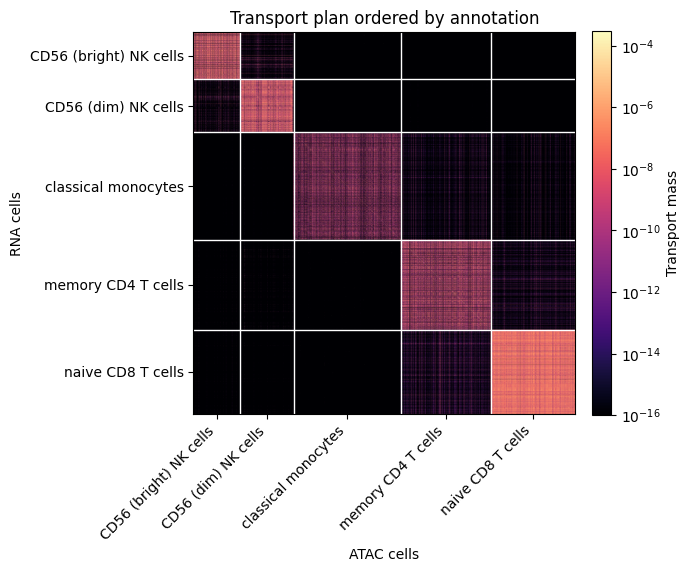

In [10]:
rna_labels = adata_rna.obs[CELLTYPE_KEY].astype(str).to_numpy()
atac_labels = adata_atac.obs[CELLTYPE_KEY].astype(str).to_numpy()
celltype_order = sorted(pd.unique(np.concatenate([rna_labels, atac_labels])))

_, _, _, fig, ax = plot_ordered_transport_plan(
    heat_mtx=plan,
    annotations=rna_labels,
    annotations_ordered=celltype_order,
    annotations_2=atac_labels,
    annotations_ordered_2=celltype_order,
    cmap="magma",
    figsize=(7, 7),
    vmin=1e-16,
    xlabel="ATAC cells",
    ylabel="RNA cells",
)
plt.show()

## Transfer cell type annotations from RNA to ATAC

A common use case is to transfer annotations from a well-annotated modality to another modality. Here we transfer RNA cell type labels to ATAC cells through the transport plan and compare the predictions with the known labels of ATAC cells.

In [11]:
transfer = transport.transfer_obs(
    CELLTYPE_KEY,
    source=RNA_MOD,
    kind="categorical",
    inplace=True,
    target_key="celltype_champollion",
    return_probabilities=True,
)

predicted = transfer["prediction"].astype(str)
true = adata_atac.obs[CELLTYPE_KEY].astype(str)
print("cell type transfer accuracy:", accuracy_score(true, predicted))
transfer["probabilities"].head()

cell type transfer accuracy: 0.9778051787916153


,CD56 (bright) NK cells,CD56 (dim) NK cells,classical monocytes,memory CD4 T cells,naive CD8 T cells
AAACAGCCAATCCCTT-1,5.878114e-25,2.227206e-18,9.914182e-07,9.995016e-01,4.973546e-04
AAACATGCAAGGTCCT-1,4.730245e-34,6.667834e-30,5.848635e-08,4.016490e-05,9.999597e-01
AAACATGCACCGGCTA-1,1.000000e+00,7.871149e-09,0.000000e+00,0.000000e+00,0.000000e+00
AAACATGCAGGGAGCT-1,9.305187e-01,6.948131e-02,0.000000e+00,3.143325e-34,9.091624e-42
AAACCAACATTGTGCA-1,0.000000e+00,0.000000e+00,9.999999e-01,3.689943e-23,3.264675e-28


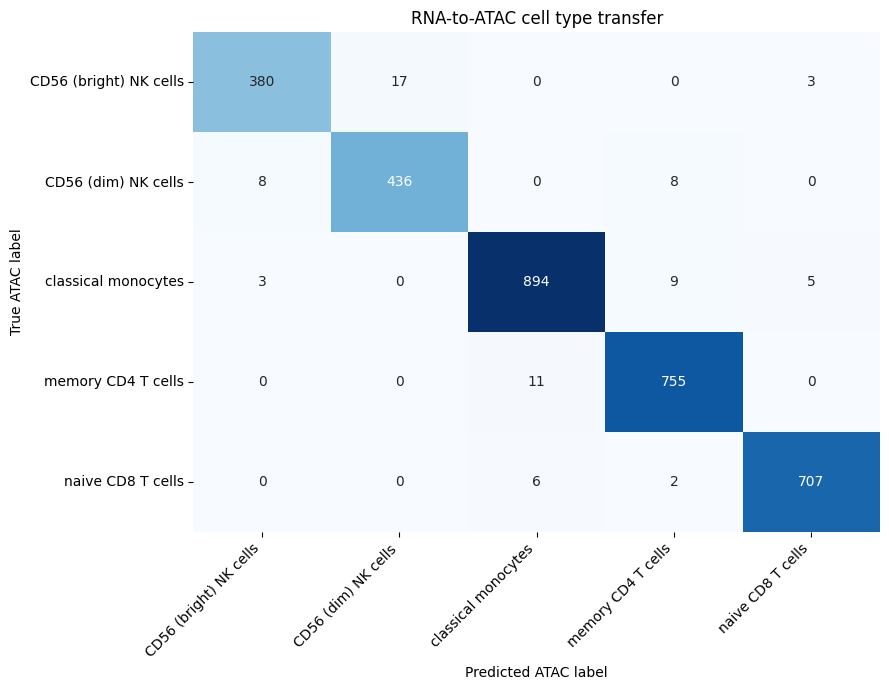

In [12]:
labels = [
    label
    for label in celltype_order
    if (true.eq(label).any() or predicted.eq(label).any())
]
cm = confusion_matrix(true, predicted, labels=labels)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    ax=ax,
)
ax.set_xlabel("Predicted ATAC label")
ax.set_ylabel("True ATAC label")
ax.set_title("RNA-to-ATAC cell type transfer")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Barycentric projection into RNA PCA space

The same transport plan can also project continuous representations across modalities. Here each ATAC cell is represented as a barycenter of RNA cells in RNA PCA space, which enables a joint visualization of original RNA cells and projected ATAC cells.

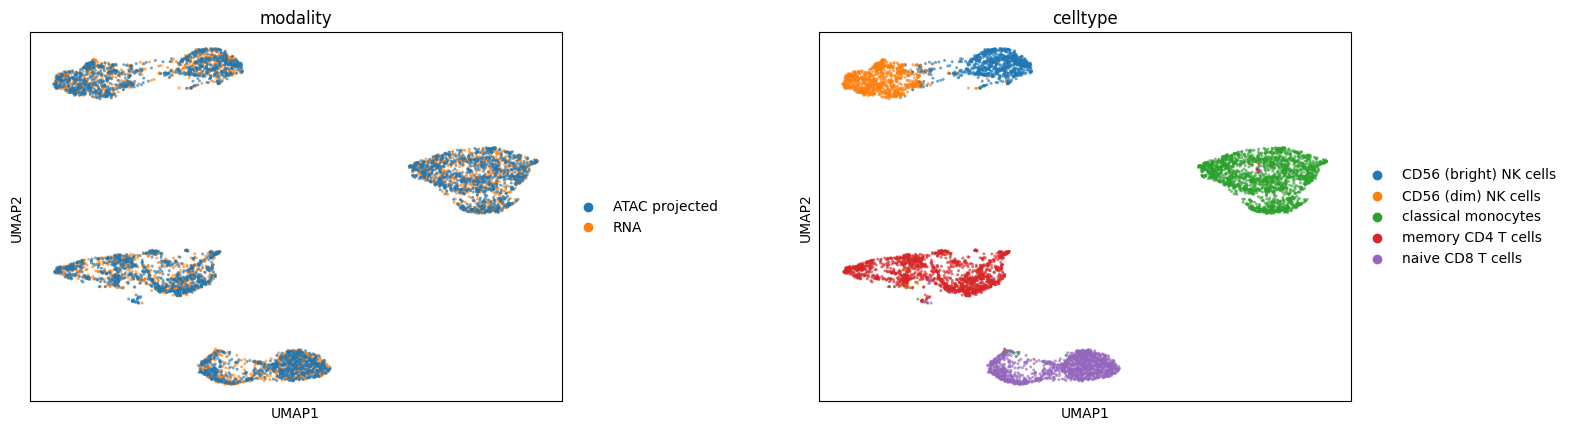

In [13]:
projected_atac_in_rna_pca = transport.project(rep="obsm/X_pca", source=RNA_MOD)

joint = ad.AnnData(X=np.vstack([adata_rna.obsm["X_pca"], projected_atac_in_rna_pca]))
joint.obs["modality"] = pd.Categorical(
    ["RNA"] * adata_rna.n_obs + ["ATAC projected"] * adata_atac.n_obs
)
joint.obs[CELLTYPE_KEY] = pd.Categorical(np.concatenate([rna_labels, atac_labels]))

sc.pp.neighbors(joint, n_neighbors=15, use_rep="X")
sc.tl.umap(joint, min_dist=0.2, random_state=0)

sc.pl.umap(joint, color=["modality", CELLTYPE_KEY], alpha=0.65, wspace=0.35)